# ACF / PACF Analysis - Kathmandu AQI Project

## 1. Load the cleaned (pre-feature-engineering) data

In [2]:
# Auto-correlation and partial auto-correlation plots for each station's PM2.5 time series

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

df = pd.read_csv("../data/processed/kathmandu_merged.csv")
df["datetime_utc"] = pd.to_datetime(df["datetime_utc"])
df = df.sort_values(["station", "datetime_utc"]).reset_index(drop=True)

teku = df[df["station"] == "teku"].set_index("datetime_utc")["pm25"]
mid_b = df[df["station"] == "mid_baneshwor"].set_index("datetime_utc")["pm25"]

print(f"Teku series length: {len(teku)}, missing: {teku.isna().sum()}")
print(f"Mid Baneshwor series length: {len(mid_b)}, missing: {mid_b.isna().sum()}")

Teku series length: 6792, missing: 2359
Mid Baneshwor series length: 6783, missing: 2871


## 2. Handle missing values for ACF/PACF

In [3]:
teku_filled = teku.interpolate(method="linear", limit_direction="both").dropna()
mid_b_filled = mid_b.interpolate(method="linear", limit_direction="both").dropna()

print(f"Teku (for ACF/PACF): {len(teku_filled)} points")
print(f"Mid Baneshwor (for ACF/PACF): {len(mid_b_filled)} points")

Teku (for ACF/PACF): 6792 points
Mid Baneshwor (for ACF/PACF): 6783 points


## 3. ACF and PACF plots for Teku

**ACF** shows correlation between the series and its lagged versions (includes indirect effects through intermediate lags).
**PACF** shows the *direct* correlation at each lag, controlling for shorter lags - this is more useful for deciding which specific lags to include as features, since it isolates each lag's independent contribution.

Plotted out to 72 hours (3 days) to check for daily (24h) and multi-day patterns.

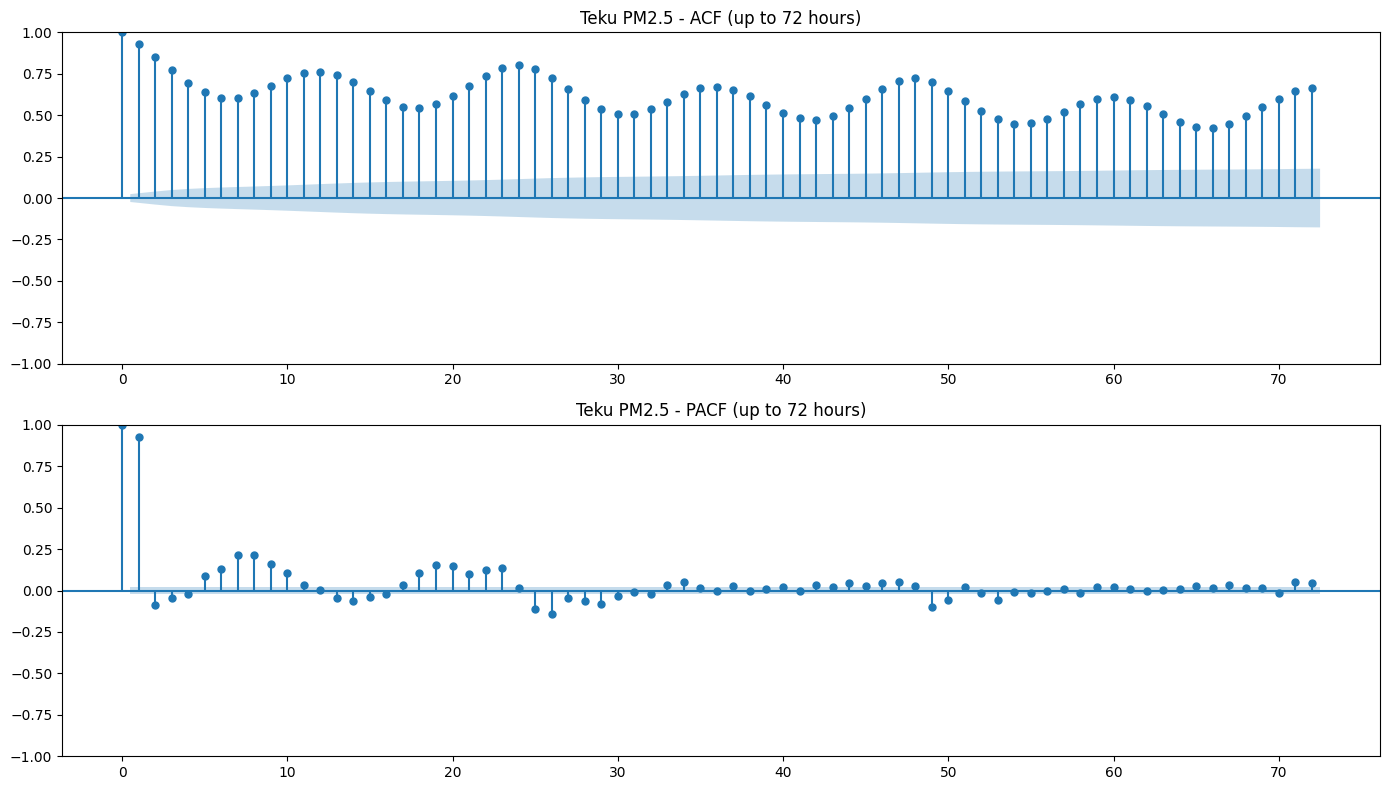

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(teku_filled, lags=72, ax=axes[0])
axes[0].set_title("Teku PM2.5 - ACF (up to 72 hours)")
plot_pacf(teku_filled, lags=72, ax=axes[1], method="ywm")
axes[1].set_title("Teku PM2.5 - PACF (up to 72 hours)")
plt.tight_layout()
plt.show()

## 4. ACF and PACF plots for Mid Baneshwor

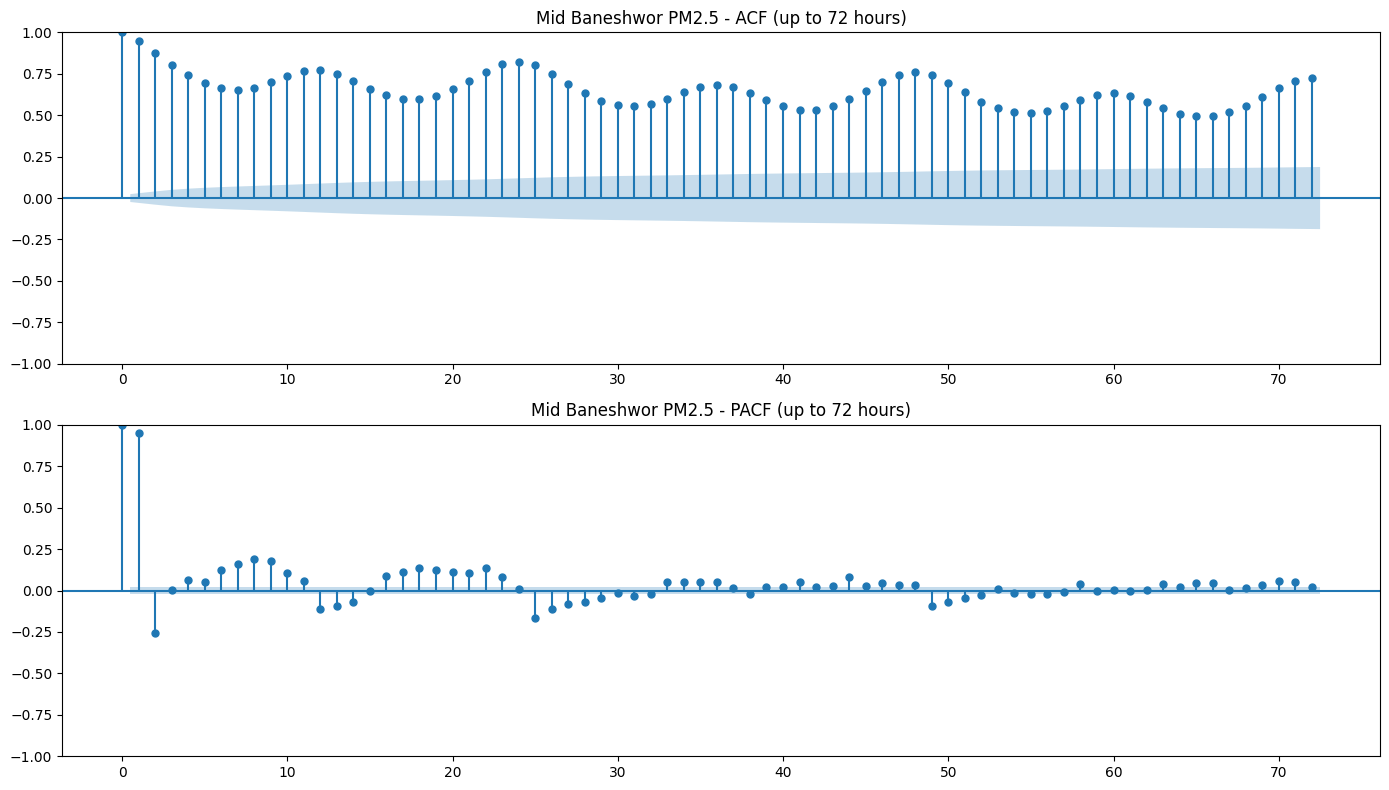

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(mid_b_filled, lags=72, ax=axes[0])
axes[0].set_title("Mid Baneshwor PM2.5 - ACF (up to 72 hours)")
plot_pacf(mid_b_filled, lags=72, ax=axes[1], method="ywm")
axes[1].set_title("Mid Baneshwor PM2.5 - PACF (up to 72 hours)")
plt.tight_layout()
plt.show()

## 5. Extract the actual strongest lags numerically

In [9]:
def top_pacf_lags(series, n_lags=72, top_n=10):
    pacf_values = pacf(series, nlags=n_lags, method="ywm")
    # Skip lag 0 (always 1.0, correlation with itself)
    lag_series = pd.Series(pacf_values[1:], index=range(1, n_lags + 1))
    return lag_series.abs().sort_values(ascending=False).head(top_n)

print("Teku - top 10 PACF lags by |correlation|:")
print(top_pacf_lags(teku_filled))

print()
print("Mid Baneshwor - top 10 PACF lags by |correlation|:")
print(top_pacf_lags(mid_b_filled))

Teku - top 10 PACF lags by |correlation|:
1     0.928267
8     0.214002
7     0.213615
9     0.159784
19    0.155094
20    0.150435
26    0.143662
23    0.137196
6     0.127551
22    0.122582
dtype: float64

Mid Baneshwor - top 10 PACF lags by |correlation|:
1     0.950114
2     0.253468
8     0.190040
9     0.180776
25    0.163796
7     0.163037
18    0.135339
22    0.134054
6     0.126223
19    0.125631
dtype: float64
